# **1 – Introduction**

# Missing Value Handling - Beginner Guide

In this notebook you will learn:

✅ What are Missing Values

✅ Why Missing Values are a Problem

✅ How to Detect Missing Values

✅ How to Create Missing Values

✅ How to Handle Missing Values

✅ Mean Imputation

✅ Median Imputation

✅ Mode Imputation

Target Audience:

- School Students
- Python Beginners
- Data Analyst Aspirants

# **2 – Real Life Example**

# What are Missing Values?

Imagine a school report card.

| Student | Maths |
|----------|--------|
| Ram | 90 |
| John | 80 |
| Ravi | ? |

Ravi's mark is missing.

This missing value is represented as:

NaN

NaN = Not a Number

# **3 – Load Dataset**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

car_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/auto_mpg_binarised.csv')

car_data.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_high
0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,0
1,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,0
2,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,0
3,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,0
4,8,302.0,140.0,3449.0,10.5,70,1,ford torino,0


# **4 – Check Missing Values**

In [3]:
car_data.isnull().sum()

,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
car_name,0
mpg_high,0


# What happened?

isnull()

Checks whether a value is missing.

sum()

Counts how many missing values exist in each column.

# **5 – Total Missing Values**

In [4]:
total_missing_values = car_data.isnull().sum().sum()

print(total_missing_values)

0


# Breakdown of code

car_data.isnull().**sum()**

returns missing count of each column

car_data.isnull().sum().**sum()**

adding all the missing count to find the total missing value

# **7 – Create Dataset Copy**

In [5]:
car_data_copy = car_data.copy()
car_data_copy

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_high
0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,0
1,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,0
2,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,0
3,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,0
4,8,302.0,140.0,3449.0,10.5,70,1,ford torino,0
...,...,...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl,1
394,4,97.0,52.0,2130.0,24.6,82,2,vw pickup,1
395,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage,1
396,4,120.0,79.0,2625.0,18.6,82,1,ford ranger,1


Never modify the original dataset.

Always work on a copy.

# **8 – Import NumPy**

In [6]:
import numpy as np

# **9 – Select Numeric Columns**

In [7]:
numeric_columns = car_data_copy.select_dtypes(include=np.number).columns


numeric_columns = ['displacement', 'horsepower', 'weight', 'acceleration']
numeric_columns

['displacement', 'horsepower', 'weight', 'acceleration']

Only numerical columns are selected.

Example:

* weight
* horsepower
* acceleration

# **10 – Create 10% Missing Values**

In [8]:
np.random.seed(45)
ten_percent_car_data_missing = int(0.1 * len(car_data_copy))

for column in numeric_columns:
  random_rows = np.random.choice(car_data_copy.index, ten_percent_car_data_missing, replace=False)
  car_data_copy.loc[random_rows, column] = np.nan

car_data_copy


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_high
0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,0
1,8,350.0,NaN,3693.0,11.5,70,1,buick skylark 320,0
2,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,0
3,8,304.0,NaN,3433.0,12.0,70,1,amc rebel sst,0
4,8,NaN,140.0,3449.0,10.5,70,1,ford torino,0
...,...,...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790.0,NaN,82,1,ford mustang gl,1
394,4,97.0,52.0,2130.0,24.6,82,2,vw pickup,1
395,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage,1
396,4,120.0,79.0,2625.0,18.6,82,1,ford ranger,1


**Step 1:**

Set a random seed value (45) so that the same rows are selected every time the code runs.

**Step 2:**

Calculate 10% of the total rows in the dataset.

For example:
If the dataset contains 398 rows,

10% of 398 = 39 rows

**Step 3:**

Loop through each numeric column in the dataset.

Examples:
- displacement
- horsepower
- weight
- acceleration

**Step 4:**

Randomly select 39 row numbers from the dataset without repeating any row.

**Step 5:**

Replace the values in those selected rows with NaN (Missing Value).

**Step 6:**

Repeat the same process for every numeric column.

**Result:**

Each numeric column will contain approximately 10% missing values.

# **11 – Verify Missing Values**

In [9]:
car_data_copy.isnull().sum()

,0
cylinders,0
displacement,39
horsepower,39
weight,39
acceleration,39
model_year,0
origin,0
car_name,0
mpg_high,0


# **12 – Visual Explanation**

Original Dataset

100%
Data Available

↓

Randomly Remove 10%

↓

Dataset with Missing Values

↓

Apply Imputation Techniques

# **13 – Mean Concept**

# Mean Imputation

Example:

10
20
30
NaN

Mean = (10+20+30)/3

Mean = 20

Replace NaN with 20

In [10]:
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(strategy='mean')

car_data_copy_mean = car_data_copy.copy()

car_data_copy_mean[numeric_columns] = mean_imputer.fit_transform(car_data_copy_mean[numeric_columns])

car_data_copy_mean


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_high
0,8,307.000000,130.00000,3504.0,12.000000,70,1,chevrolet chevelle malibu,0
1,8,350.000000,103.34637,3693.0,11.500000,70,1,buick skylark 320,0
2,8,318.000000,150.00000,3436.0,11.000000,70,1,plymouth satellite,0
3,8,304.000000,103.34637,3433.0,12.000000,70,1,amc rebel sst,0
4,8,192.249304,140.00000,3449.0,10.500000,70,1,ford torino,0
...,...,...,...,...,...,...,...,...,...
393,4,140.000000,86.00000,2790.0,15.582173,82,1,ford mustang gl,1
394,4,97.000000,52.00000,2130.0,24.600000,82,2,vw pickup,1
395,4,135.000000,84.00000,2295.0,11.600000,82,1,dodge rampage,1
396,4,120.000000,79.00000,2625.0,18.600000,82,1,ford ranger,1


### **13a - Mean Imputation**

This code replaces missing values (NaN) in numeric columns with the average (mean) value of that column.

**Step 1:** Import `SimpleImputer`, a tool used to fill missing values.

**Step 2:** Create a Mean Imputer by setting `strategy='mean'`.

**Step 3:** Create a copy of the dataset to avoid modifying the original data.

**Step 4:** Calculate the mean value for each numeric column.

**Step 5:** Replace all missing values in those columns with their respective mean values.

**Step 6:** Display the updated dataset.

**Result:** All missing values in the numeric columns are replaced with the column average.


### **13b – Check Missing Values Again**

In [11]:
car_data_copy_mean.isnull().sum()

,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
car_name,0
mpg_high,0


**Result:**

All missing values should become 0.

# **14 – Median Concept**

# Median Imputation

Values:

10
20
30
500

Median = 25

Median is less affected by outliers.

In [12]:
median_imputer = SimpleImputer(strategy='median')

car_data_copy_median = car_data_copy.copy()

car_data_copy_median[numeric_columns] = median_imputer.fit_transform(car_data_copy_median[numeric_columns])

car_data_copy_median

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_high
0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,0
1,8,350.0,93.0,3693.0,11.5,70,1,buick skylark 320,0
2,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,0
3,8,304.0,93.0,3433.0,12.0,70,1,amc rebel sst,0
4,8,151.0,140.0,3449.0,10.5,70,1,ford torino,0
...,...,...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790.0,15.5,82,1,ford mustang gl,1
394,4,97.0,52.0,2130.0,24.6,82,2,vw pickup,1
395,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage,1
396,4,120.0,79.0,2625.0,18.6,82,1,ford ranger,1


### **14a - Median Imputation**

This code replaces missing values (NaN) in numeric columns with the center (median) value of that column after it is sorted.

**Step 1:** Import `SimpleImputer`, a tool used to fill missing values.

**Step 2:** Create a Median Imputer by setting `strategy='median'`.

**Step 3:** Create a copy of the dataset to avoid modifying the original data.

**Step 4:** Calculate the median value for each numeric column.

**Step 5:** Replace all missing values in those columns with their respective median values.

**Step 6:** Display the updated dataset.

**Result:** All missing values in the numeric columns are replaced with the column center median value.

### **14b – Check Missing Values Again**

In [13]:
car_data_copy_median.isnull().sum()

,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
car_name,0
mpg_high,0


**Result:**

All missing values should become 0.

# **15 – Mode Concept**

# Mode Imputation

Values:

4
4
4
6
8

Most Frequent Value = 4

Mode = 4

In [14]:
mode_imputer = SimpleImputer(strategy='most_frequent')
car_data_copy_mode = car_data_copy.copy()
car_data_copy_mode[numeric_columns] = mode_imputer.fit_transform(car_data_copy_mode[numeric_columns])
car_data_copy_mode

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_high
0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,0
1,8,350.0,150.0,3693.0,11.5,70,1,buick skylark 320,0
2,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,0
3,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,0
4,8,97.0,140.0,3449.0,10.5,70,1,ford torino,0
...,...,...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790.0,14.5,82,1,ford mustang gl,1
394,4,97.0,52.0,2130.0,24.6,82,2,vw pickup,1
395,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage,1
396,4,120.0,79.0,2625.0,18.6,82,1,ford ranger,1


### **15a - Mode Imputation**

This code replaces missing values (NaN) in numeric columns with the most frequent (mode) value of that column after it is sorted.

**Step 1:** Import `SimpleImputer`, a tool used to fill missing values.

**Step 2:** Create a Median Imputer by setting `strategy='most_frequent'`.

**Step 3:** Create a copy of the dataset to avoid modifying the original data.

**Step 4:** Calculate the mode value for each numeric column.

**Step 5:** Replace all missing values in those columns with their respective mode values.

**Step 6:** Display the updated dataset.

**Result:** All missing values in the numeric columns are replaced with the column's most frequent values.

### **15b – Check Missing Values Again**

In [15]:
car_data_copy_mode.isnull().sum()

,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
car_name,0
mpg_high,0


**Result:**

All missing values should become 0.

# **16 - Imputation by mode within each class**



In [16]:
car_data_copy_mode_class = car_data_copy.copy()
for car_class in car_data_copy_mode_class['mpg_high'].unique():
  class_mask = car_data_copy_mode_class['mpg_high'] == car_class
  class_df = car_data_copy_mode_class.loc[class_mask, numeric_columns]
  class_mode = class_df.mode().iloc[0]
  car_data_copy_mode_class.loc[class_mask, numeric_columns] = class_df.fillna(class_mode)
car_data_copy_mode_class

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_high
0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,0
1,8,350.0,150.0,3693.0,11.5,70,1,buick skylark 320,0
2,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,0
3,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,0
4,8,318.0,140.0,3449.0,10.5,70,1,ford torino,0
...,...,...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790.0,14.5,82,1,ford mustang gl,1
394,4,97.0,52.0,2130.0,24.6,82,2,vw pickup,1
395,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage,1
396,4,120.0,79.0,2625.0,18.6,82,1,ford ranger,1


In [17]:
# 1. Create the copy
car_data_copy_mode_class = car_data_copy.copy()

# 2. Group by 'mpg_high', find the mode for each group, and fill NaNs in one shot
car_data_copy_mode_class[numeric_columns] = (
    car_data_copy_mode_class
    .groupby('mpg_high')[numeric_columns]
    .transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan))
)

car_data_copy_mode_class

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_high
0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,0
1,8,350.0,150.0,3693.0,11.5,70,1,buick skylark 320,0
2,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,0
3,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,0
4,8,318.0,140.0,3449.0,10.5,70,1,ford torino,0
...,...,...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790.0,14.5,82,1,ford mustang gl,1
394,4,97.0,52.0,2130.0,24.6,82,2,vw pickup,1
395,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage,1
396,4,120.0,79.0,2625.0,18.6,82,1,ford ranger,1


# **What happens here?**

## ***A. Group the data by mpg_high***

`.groupby('mpg_high')`

Suppose mpg_high has two classes:

|mpg_high |	horsepower|
----------|-------------
|High |	100|
|High |	NaN|
|High	| 120|
|Low |	80|
|Low |	NaN|
|Low |	80|

The data is split into:

- High group
- Low group

## ***B. Find the Mode of Each Numeric Column in Each Group***
`x.mode()`

For the "Low" group:

|horsepower|
|-----------|
|80 |
|NaN |
|80 |

Mode = 80 (most frequent value)

## ***C. Fill Missing Values with the Group's Mode***

`x.fillna(x.mode().iloc[0])`

Before:

|mpg_high |	horsepower|
----------|-------------
|Low |	80|
|Low |	NaN|
|Low |	80|

After:

|mpg_high |	horsepower|
----------|-------------
|Low |	80|
|Low |	80|
|Low |	80|

## ***D. Safety Check***

`if not x.mode().empty else np.nan`

If a column contains only missing values and has no mode, keep it as NaN.


# **17 – Compare Results**

In [18]:
print("Original Dataset")
print(car_data_copy.isnull().sum().sum())

print("Mean Imputation")
print(car_data_copy_mean.isnull().sum().sum())

print("Median Imputation")
print(car_data_copy_median.isnull().sum().sum())

print("Mode Imputation")
print(car_data_copy_mode.isnull().sum().sum())

print("Mode by Class Imputation")
print(car_data_copy_mode_class.isnull().sum().sum())

Original Dataset
156
Mean Imputation
0
Median Imputation
0
Mode Imputation
0
Mode by Class Imputation
0


# Principal Component Analysis (PCA)

## Objective

The objective of this notebook is to perform **Principal Component Analysis (PCA)** on the car dataset. PCA is a dimensionality reduction technique that transforms multiple correlated features into a smaller number of uncorrelated variables called **Principal Components (PCs)** while preserving most of the original information.

---

# Step 1: Import Required Libraries

We first import the necessary Python libraries required for data preprocessing, PCA, visualization, and data manipulation.

**Libraries used:**

* **Pandas** – Used to work with tabular data.
* **NumPy** – Used for numerical computations.
* **Matplotlib** – Used to visualize the PCA results.
* **StandardScaler** – Standardizes the features before applying PCA.
* **PCA** – Performs Principal Component Analysis.

---

# Step 2: Create the PCA Analysis Function

A reusable function named **`analyze_pca()`** is created to perform PCA on any dataset.

### Function Parameters

| Parameter       | Description                              |
| --------------- | ---------------------------------------- |
| `test_df`       | Dataset to be analyzed                   |
| `data_set_name` | Dataset name used in plot titles         |
| `original_df`   | Optional original dataset for comparison |

---

# Step 3: Select Features

Only the numerical columns are selected because PCA works only with numerical data.

The target column **`mpg_high`** is stored separately and is later used to color the scatter plot.

---

# Step 4: Standardize the Data

Before applying PCA, all numerical features are standardized using **StandardScaler**.

Standardization transforms every feature so that:

* Mean = 0
* Standard Deviation = 1

This prevents features with larger values from dominating the PCA calculation.

---

# Step 5: Apply PCA

The standardized data is transformed into **Principal Components** using the PCA algorithm.

Each Principal Component is a linear combination of the original features.

The first component (**PC1**) captures the maximum variance in the data.

The second component (**PC2**) captures the next highest variance while remaining independent of PC1.

---

# Step 6: Calculate Explained Variance

The explained variance ratio tells us how much information each Principal Component retains from the original dataset.

For example:

* PC1 = 58%
* PC2 = 22%

This means the first two components together preserve **80% of the original information**.

---

# Step 7: Display the Loadings Matrix

The Loadings Matrix shows the contribution of each original feature to every Principal Component.

A higher positive or negative loading indicates that the feature has a stronger influence on that component.

---

# Step 8: Visualize Feature Contributions

A bar chart is created to display the contribution of each feature to **PC1**.

This visualization helps identify the most influential variables in the dataset.

---

# Step 9: Create the PCA Scatter Plot

The first two Principal Components (**PC1 and PC2**) are plotted in a scatter plot.

Each point represents one observation from the dataset.

The points are colored using the **`mpg_high`** target variable, making it easier to observe whether the classes are naturally separated.

---

# Step 10: Compare Datasets (Optional)

If an original dataset is provided, the notebook displays two PCA scatter plots side by side:

* **Original Dataset**
* **Modified Dataset**

This comparison helps visualize how preprocessing techniques (such as missing value treatment, scaling, or outlier handling) affect the distribution of the data.

---

# Conclusion

This notebook demonstrates the complete PCA workflow:

* Import the required libraries.
* Standardize the numerical features.
* Apply Principal Component Analysis.
* Measure the variance explained by each component.
* Analyze feature contributions using the Loadings Matrix.
* Visualize the transformed data using PCA scatter plots.
* Compare the original and transformed datasets when required.

The PCA results help us understand the structure of the dataset, identify the most important features, and reduce dimensionality while preserving most of the original information.

---


In [19]:
# Step 1: Import Required Libraries
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Step 2: Create a reusable function to perform PCA analysis
def analyze_pca(test_df, data_set_name, original_df=None):

    # Step 3: Select the numerical features and target column
    x = test_df[numeric_columns]
    y = test_df["mpg_high"].astype(str)

    # Step 4: Standardize the numerical features
    # This ensures every feature has equal importance before applying PCA.
    standardscaler = StandardScaler()
    x_scaled = standardscaler.fit_transform(x)

    # Step 5: Apply PCA to transform the standardized data
    pca = PCA()
    x_pca = pca.fit_transform(x_scaled)

    # Step 6: Calculate and display the explained variance
    # This shows how much information each Principal Component retains.
    exp_var = pca.explained_variance_ratio_ * 100

    print("Explained Variance")
    print("------------------")
    for i, variance in enumerate(exp_var):
        print(f"PC{i+1}: {variance:.2f}%")

    # Step 7: Create the Loadings Matrix
    # The loadings indicate how much each original feature contributes
    # to each Principal Component.
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)],
        index=numeric_columns
    )

    print("\nLoadings Matrix")
    print(loadings)

    # Step 8: Visualize the feature contributions for PC1
    plt.figure(figsize=(8, 4))
    loadings["PC1"].plot(
        kind="bar",
        color="darkcyan",
        title=f"Feature Contributions to PC1 - {data_set_name}"
    )
    plt.ylabel("Contribution")
    plt.tight_layout()
    plt.show()

    # Step 9: Create a PCA scatter plot using the first two Principal Components
    def biplot(x_new_scaled, title):

        # Apply PCA with only two principal components
        pca_2 = PCA(n_components=2)
        principal_components_2 = pca_2.fit_transform(x_new_scaled)

        # Store PC1 and PC2 in a DataFrame
        pca_2_df = pd.DataFrame(
            principal_components_2,
            columns=["PC1", "PC2"]
        )

        # # Approach 1: Plot the transformed data in a single call
        # plt.scatter(
        #     pca_2_df["PC1"],
        #     pca_2_df["PC2"],
        #     alpha=0.5,
        #     c=test_df["mpg_high"],
        #     cmap="coolwarm"
        # )

        # Approach 2: Plot the transformed data in a two different calls
        # based on the split determined using mpg_high
        high = pca_2_df[test_df["mpg_high"] == 1]

        # print("High")
        # print(high)

        low = pca_2_df[test_df["mpg_high"] == 0]

        print("Low")
        print(low)

        # Plot mpg_high = 0
        plt.scatter(
            low["PC1"],
            low["PC2"],
            color="blue",
            alpha=0.4,
            label="Low MPG (0)"
        )

        # Plot mpg_high = 1
        plt.scatter(
            high["PC1"],
            high["PC2"],
            color="red",
            alpha=0.4,
            label="High MPG (1)"
        )

        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title(title)
        plt.legend(title="MPG Class")
        plt.grid(True)

    # Step 10: Display the PCA scatter plot
    # If an original dataset is provided, compare both datasets.
    if original_df is None:

        plt.figure(figsize=(6, 5))
        biplot(x_scaled, "Original Car Dataset")
        plt.tight_layout()

    else:

        # Standardize the original dataset
        org_x = original_df[numeric_columns]

        org_scaler = StandardScaler()
        org_x_scaled = org_scaler.fit_transform(org_x)

        # Create side-by-side comparison plots
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))

        plt.sca(axs[0])
        biplot(org_x_scaled, "Original Car Dataset")

        plt.sca(axs[1])
        biplot(x_scaled, data_set_name)

        plt.tight_layout()

    plt.show()

Explained Variance
------------------
PC1: 80.07%
PC2: 16.34%
PC3: 2.23%
PC4: 1.37%

Loadings Matrix
                   PC1       PC2       PC3       PC4
displacement  0.534895  0.250421 -0.452460 -0.668174
horsepower    0.540960 -0.029110  0.828942 -0.139179
weight        0.513193  0.437846 -0.200233  0.710514
acceleration -0.397346  0.862979  0.260850 -0.171293


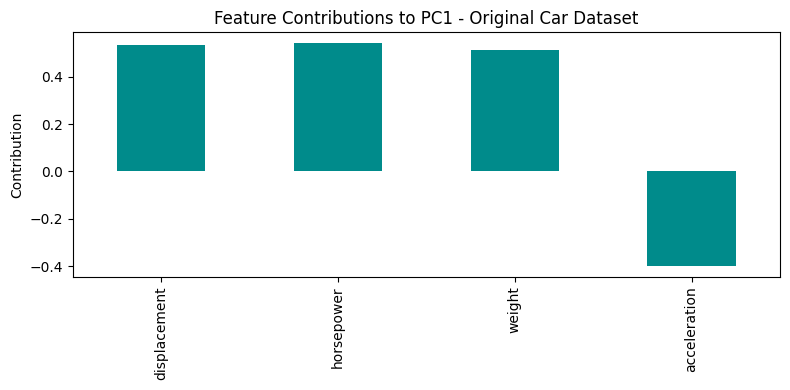

Low
          PC1       PC2
0    1.783885 -0.588133
1    2.687840 -0.570260
2    2.226980 -0.925474
3    2.008983 -0.647364
4    2.083026 -1.106254
..        ...       ...
363  0.507713  0.388948
365 -0.366412  0.554739
366  0.037335  0.670144
374 -0.890249  1.476721
389  0.347976 -0.255093

[207 rows x 2 columns]


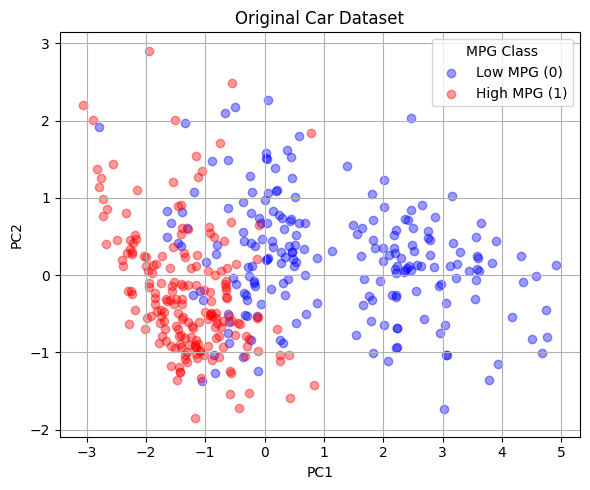

In [20]:
analyze_pca(car_data, "Original Car Dataset")

Explained Variance
------------------
PC1: 73.78%
PC2: 17.07%
PC3: 5.49%
PC4: 3.67%

Loadings Matrix
                   PC1       PC2       PC3       PC4
displacement  0.536573  0.217042 -0.532294 -0.617774
horsepower    0.535808  0.016394  0.812536 -0.228967
weight        0.518468  0.427328 -0.145888  0.726154
acceleration -0.395210  0.877505  0.187522 -0.196544


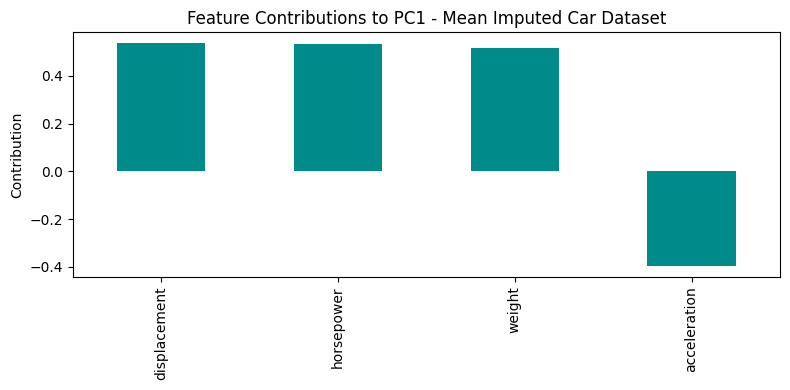

Low
          PC1       PC2
0    1.783885 -0.588133
1    2.687840 -0.570260
2    2.226980 -0.925474
3    2.008983 -0.647364
4    2.083026 -1.106254
..        ...       ...
363  0.507713  0.388948
365 -0.366412  0.554739
366  0.037335  0.670144
374 -0.890249  1.476721
389  0.347976 -0.255093

[207 rows x 2 columns]
Low
          PC1       PC2
0    1.914568 -0.644503
1    1.938190 -0.628178
2    2.386860 -0.980014
3    1.444545 -0.701318
4    1.630769 -1.421976
..        ...       ...
363  0.566294  0.396634
365 -0.135694  0.056784
366  0.063177  0.664674
374 -0.904904  1.580896
389  0.176612 -0.362402

[207 rows x 2 columns]


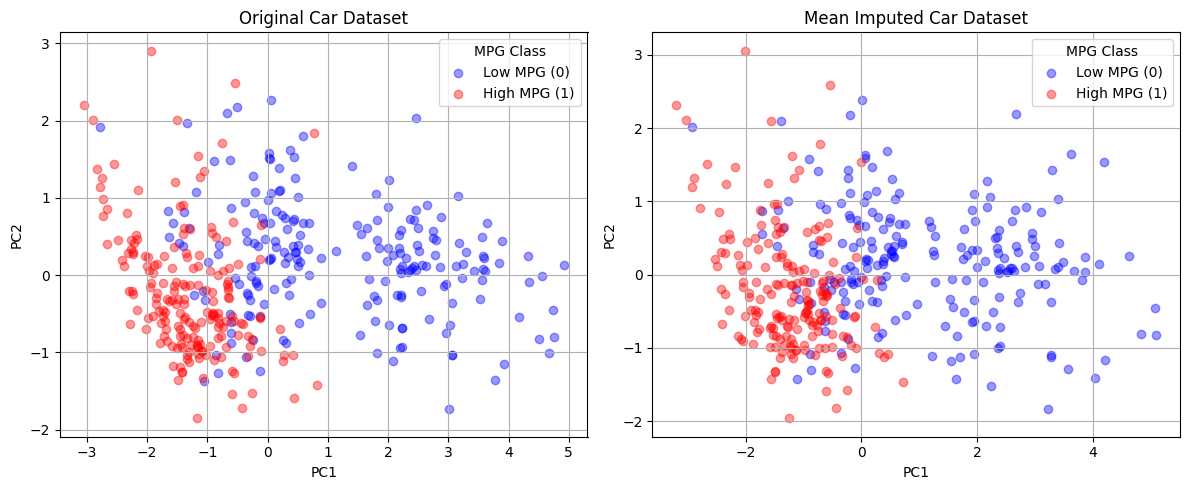

In [21]:
analyze_pca(car_data_copy_mean, "Mean Imputed Car Dataset", original_df=car_data)

Explained Variance
------------------
PC1: 69.59%
PC2: 17.53%
PC3: 7.20%
PC4: 5.68%

Loadings Matrix
                   PC1       PC2       PC3       PC4
displacement  0.538811  0.203637 -0.425576  0.697925
horsepower    0.534370  0.001760  0.839453  0.098818
weight        0.510621  0.465229 -0.245980 -0.679943
acceleration -0.404224  0.861447  0.231729  0.202023


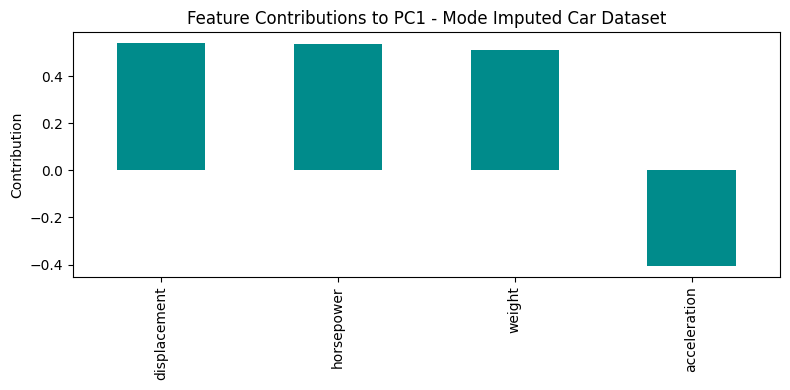

Low
          PC1       PC2
0    1.783885 -0.588133
1    2.687840 -0.570260
2    2.226980 -0.925474
3    2.008983 -0.647364
4    2.083026 -1.106254
..        ...       ...
363  0.507713  0.388948
365 -0.366412  0.554739
366  0.037335  0.670144
374 -0.890249  1.476721
389  0.347976 -0.255093

[207 rows x 2 columns]
Low
          PC1       PC2
0    1.871283 -0.538448
1    2.570401 -0.511511
2    2.324756 -0.877100
3    2.096938 -0.582057
4    1.102695 -1.472717
..        ...       ...
363  0.555421  0.494237
365  0.066269 -0.183262
366  0.077061  0.767921
374 -0.886766  1.653638
389 -0.300323 -0.444504

[207 rows x 2 columns]


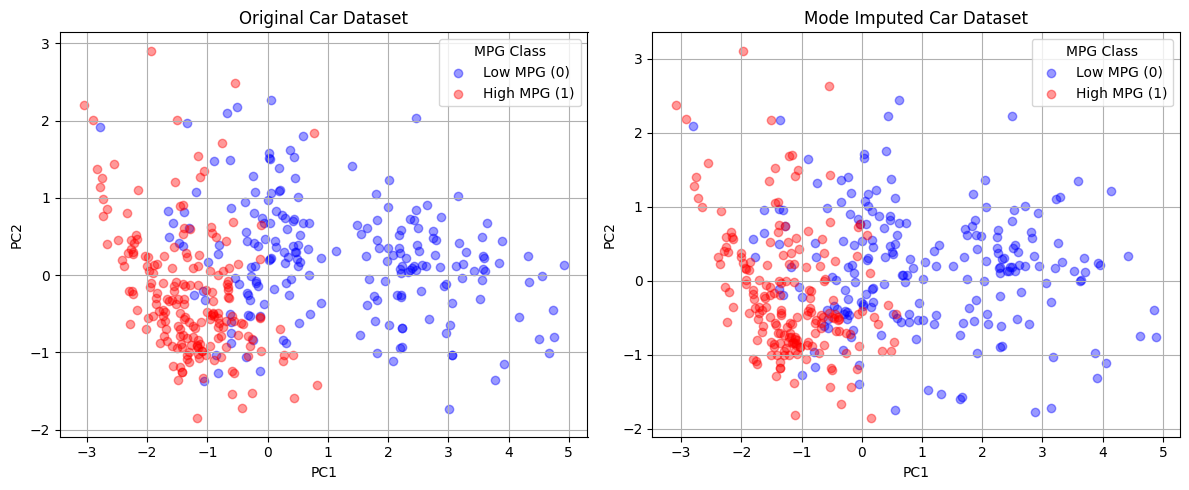

In [22]:
analyze_pca(car_data_copy_mode, "Mode Imputed Car Dataset", original_df=car_data)

Explained Variance
------------------
PC1: 73.15%
PC2: 17.11%
PC3: 5.96%
PC4: 3.78%

Loadings Matrix
                   PC1       PC2       PC3       PC4
displacement  0.535009  0.219862 -0.574513 -0.579103
horsepower    0.534828  0.012936  0.794006 -0.288696
weight        0.519879  0.429052 -0.090623  0.733094
acceleration -0.396798  0.876018  0.176851 -0.209446


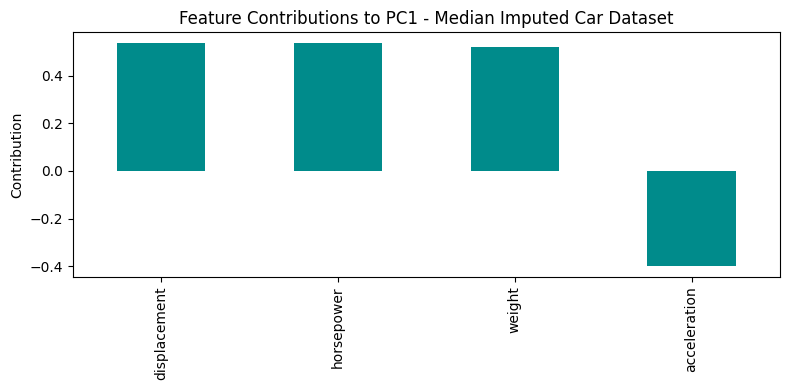

Low
          PC1       PC2
0    1.783885 -0.588133
1    2.687840 -0.570260
2    2.226980 -0.925474
3    2.008983 -0.647364
4    2.083026 -1.106254
..        ...       ...
363  0.507713  0.388948
365 -0.366412  0.554739
366  0.037335  0.670144
374 -0.890249  1.476721
389  0.347976 -0.255093

[207 rows x 2 columns]
Low
          PC1       PC2
0    1.954524 -0.622550
1    1.820935 -0.606361
2    2.425008 -0.959439
3    1.329504 -0.680619
4    1.454570 -1.493091
..        ...       ...
363  0.610057  0.417415
365 -0.075929  0.051809
366  0.109003  0.687487
374 -0.859056  1.598153
389 -0.000012 -0.433853

[207 rows x 2 columns]


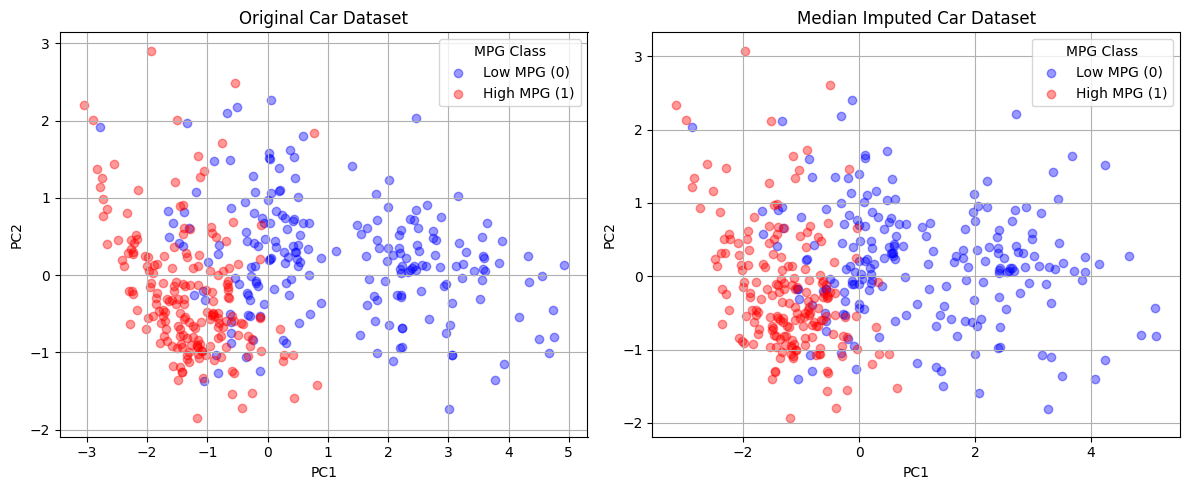

In [23]:
analyze_pca(car_data_copy_median, "Median Imputed Car Dataset", original_df=car_data)

Explained Variance
------------------
PC1: 76.83%
PC2: 17.11%
PC3: 3.43%
PC4: 2.63%

Loadings Matrix
                   PC1       PC2       PC3       PC4
displacement  0.540792  0.205584 -0.268962  0.770025
horsepower    0.542169  0.018215  0.834791 -0.094047
weight        0.513884  0.426917 -0.412810 -0.619074
acceleration -0.386677  0.880423  0.245705  0.122330


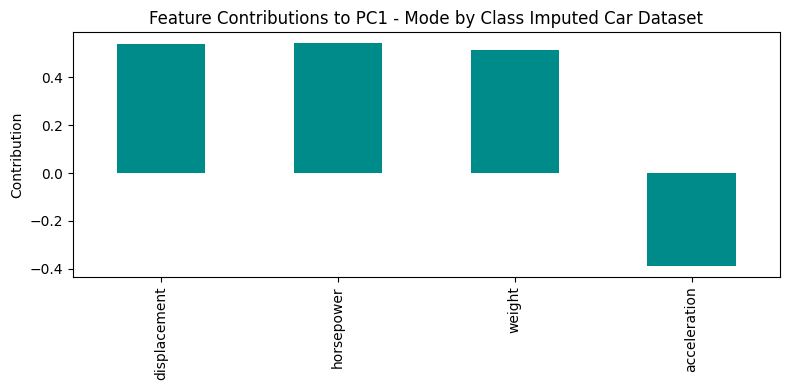

Low
          PC1       PC2
0    1.783885 -0.588133
1    2.687840 -0.570260
2    2.226980 -0.925474
3    2.008983 -0.647364
4    2.083026 -1.106254
..        ...       ...
363  0.507713  0.388948
365 -0.366412  0.554739
366  0.037335  0.670144
374 -0.890249  1.476721
389  0.347976 -0.255093

[207 rows x 2 columns]
Low
          PC1       PC2
0    1.806400 -0.588867
1    2.510131 -0.561292
2    2.257480 -0.920278
3    2.039015 -0.621417
4    2.191518 -1.082502
..        ...       ...
363  0.518066  0.452229
365  0.148081 -0.556264
366  0.037577  0.716201
374 -0.889193  1.638331
389  0.798215 -0.033925

[207 rows x 2 columns]


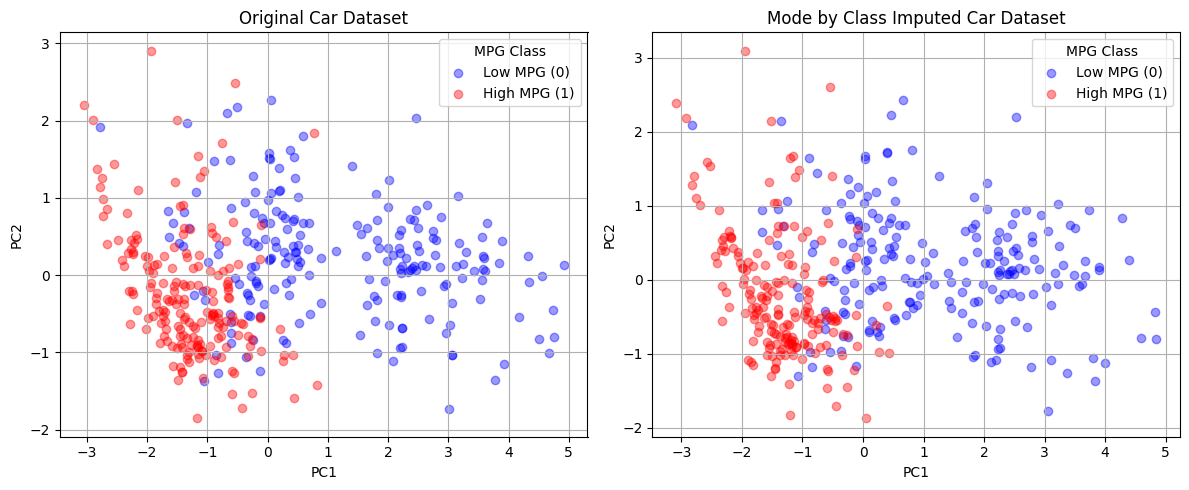

In [24]:
analyze_pca(car_data_copy_mode_class, "Mode by Class Imputed Car Dataset", original_df=car_data)

# **18 – Exercises**

# Practice Exercises

Exercise 1

Create 20% missing values instead of 10%.

--------------------------------

Exercise 2

Find which column contains the most missing values.

--------------------------------

Exercise 3

Calculate total missing values.

--------------------------------

Exercise 4

Apply Mean Imputation.

--------------------------------

Exercise 5

Apply Median Imputation.

--------------------------------

Exercise 6

Compare Mean and Median results.

# **19 - Interview Questions**


1. What is a Missing Value?

2. What is NaN?

3. Why are Missing Values dangerous?

4. Difference between Mean and Median?

5. When should Median be preferred?

6. What is Mode?

7. What is Imputation?

8. Why do we create a copy of the dataset?

9. What is SimpleImputer?

10. Which imputation method would you choose for skewed data?

# **20 – Summary**

# What You Learned

✅ Missing Values

✅ NaN

✅ isnull()

✅ Creating Missing Values

✅ Mean Imputation

✅ Median Imputation

✅ Mode Imputation

